# Melbourne Myki Tram Network Analysis — 2017

---

**Student Name:** *(MD Kawser Islam)*  
**Student Number:** *(225586507)*  
**Email:** *(s225586507@deakin.edu.au)*  
**Unit:** SIT731 (Postgraduate)

---

## Introduction

This report analyses a sample of Myki touch-on and touch-off transactions recorded across the 20 busiest tram routes in Melbourne during 2017. The dataset comprises over 1.9 million touch-on records, approximately 611,000 touch-off records, and a comprehensive stop-location reference file containing geographic coordinates and stop details for the broader Melbourne public transport network.

The analysis proceeds through several interconnected investigations: first, the three data sources are joined into a single enriched transaction table; then, the busiest stops and routes by patronage are identified and visualised; end-to-end travel times are used to rank routes by length; and finally, hourly demand patterns are examined to characterise morning and afternoon peak periods and compare peak loading across routes. Throughout, the aim is to derive operationally meaningful insights that could inform service planning for Yarra Trams.

## 1. Data Loading and Preparation

We begin by importing the required libraries and configuring display settings. `pandas` handles all tabular operations, `matplotlib` and `seaborn` are used for visualisation, `numpy` provides numerical utilities, and `os` is used to construct file paths from the central data directory.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import display

# ── Path configuration ───────────────────────────────────────────────────────
DATA_DIR = r'D:\SIT731\Task_4P\Melbourne-Myki-Tram-Network-Analysis-Main-2017'
# ────────────────────────────────────────────────────────────────────────────

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 1.1 Loading the Transaction Files

The touch-on and touch-off CSV files share an identical schema. Each row represents one Myki transaction and contains a `stop_id` (used later to enrich with stop details), a `parent_route` (the canonical tram route number), and a `date_time` timestamp. The `business_date` column records the service day, which may differ from the calendar date for late-night services. Both files are loaded with explicit dtype declarations to avoid silent type coercions.

In [4]:
dtype_map = {
    'mode'        : 'int8',
    'card_id'     : 'int32',
    'card_type'   : 'int8',
    'vehicle_id'  : 'Int32',
    'parent_route': 'int16',
    'route_id'    : 'int32',
    'stop_id'     : 'int32',
}
parse_dates = ['business_date', 'date_time']

scan_on = pd.read_csv(
    os.path.join(DATA_DIR, 'myki_2017_top20_tram_routes_ScanOnTransaction.csv'),
    dtype=dtype_map, parse_dates=parse_dates
)
scan_off = pd.read_csv(
    os.path.join(DATA_DIR, 'myki_2017_top20_tram_routes_ScanOffTransaction.csv'),
    dtype=dtype_map, parse_dates=parse_dates
)

print(f'Touch-on records : {len(scan_on):,}')
print(f'Touch-off records: {len(scan_off):,}')
print(f'Touch-off coverage: {len(scan_off)/len(scan_on)*100:.1f}% of touch-ons have a touch-off')
print(f'Date range       : {scan_on["business_date"].min().date()} to {scan_on["business_date"].max().date()}')
print(f'Unique routes    : {sorted(scan_on["parent_route"].unique().tolist())}')
print(f'Unique stops     : {scan_on["stop_id"].nunique():,}')
display(scan_on.head(3))

Touch-on records : 1,904,721
Touch-off records: 611,293
Touch-off coverage: 32.1% of touch-ons have a touch-off
Date range       : 2017-01-01 to 2018-01-06
Unique routes    : [1, 3, 5, 6, 12, 16, 19, 48, 55, 57, 58, 59, 64, 67, 70, 72, 75, 86, 96, 109]
Unique stops     : 1,586


,mode,business_date,card_id,card_type,vehicle_id,parent_route,route_id,stop_id,date_time
0,3,2017-02-15,7639560,1,638,59,16852,19256,2017-02-15 08:57:13
1,3,2017-11-09,15240980,1,593,86,24655,6103,2017-11-09 12:30:33
2,3,2017-02-15,4672220,1,753,3,16911,19499,2017-02-15 19:58:34


**Results:** The touch-on file contains **1,904,721 records** and the touch-off file contains **611,293 records**, giving an overall touch-off coverage of approximately **32.1%** — meaning roughly **67.9% of passengers did not register a touch-off**. This high non-touch-off rate is common in Melbourne's tram network, where alighting without tapping off incurs no financial penalty and many stops lack readers.

The data spans **1 January 2017 to 6 January 2018** and covers exactly **20 tram routes**: 1, 3, 5, 6, 12, 16, 19, 48, 55, 57, 58, 59, 64, 67, 70, 72, 75, 86, 96, and 109, across **1,586 unique boarding stops**.

### 1.2 Loading and Parsing Stop Locations

The `stop_locations.txt` file is pipe-delimited (`|`) and has no header row. Each record encodes eleven fields: `stop_id`, short name, full descriptive name, stop type, suburb, postcode, city, LGA, region, latitude, and longitude. We assign column names manually. The **stop number** used as the join key is the integer `stop_id` in the first field, which corresponds directly to the `stop_id` column in both transaction files. The **stop name** used in all subsequent analysis is the short name (second field).

In [5]:
stop_cols = [
    'stop_id', 'stop_short_name', 'stop_full_name',
    'stop_type', 'suburb', 'postcode', 'city',
    'lga', 'region', 'latitude', 'longitude'
]
stops = pd.read_csv(
    os.path.join(DATA_DIR, 'stop_locations.txt'),
    sep='|', header=None, names=stop_cols, dtype={'stop_id': 'int32'}
)

print(f'Stop records loaded : {len(stops):,}')
print(f'Stop types present  : {stops["stop_type"].value_counts().to_dict()}')
display(stops.head(3))

Stop records loaded : 27,614
Stop types present  : {'Kerbside': 22880, 'Bus Bay': 3322, 'Platform': 862, 'Safety Zone': 337, 'non passenger point': 64, 'kerbside': 11, 'Layover': 1, 'Depot': 1}


,stop_id,stop_short_name,stop_full_name,stop_type,suburb,postcode,city,lga,region,latitude,longitude
0,867,Weemala Court,Weemala Ct/Plenty River Dr (Greensborough),Kerbside,Greensborough,"3,088.00",Melbourne,Banyule,Greater Metro,-37.69,145.11
1,868,Crana Grove,Crana Gr/Plenty River Dr (Greensborough),Kerbside,Greensborough,"3,088.00",Melbourne,Banyule,Greater Metro,-37.69,145.11
2,869,Punkerri Circuit,Punkerri Cct/Plenty River Dr (Greensborough),Kerbside,Greensborough,"3,088.00",Melbourne,Banyule,Greater Metro,-37.68,145.11


**Results:** The stop reference file contains **27,614 stop records** spanning trams, trains, and buses across metropolitan Melbourne. Stop types include kerbside stops, bus bays, and railway stations. Since the transaction files already carry integer `stop_id` values that directly match the first field of `stop_locations.txt`, the join to this reference table requires no string parsing or fuzzy matching.

## 2. Joining the Datasets (Q1)

The goal is to produce a single enriched table in which every touch-on record is augmented with its boarding stop details and — where available — the alighting stop details from the corresponding touch-off. The joining strategy proceeds in three steps:

1. **Touch-on ⟕ Stop locations** — a *left join* on `stop_id` attaches the boarding stop name and coordinates. A left join is used to retain all touch-on records even if a `stop_id` is absent from the reference file.

2. **Touch-on ⟕ Touch-off** — a *left join* on (`card_id`, `business_date`, `parent_route`) links each touch-on to at most one touch-off for the same card, service day, and route. A left join preserves touch-on rows with no corresponding touch-off.

3. **Result ⟕ Stop locations** — a second left join enriches the touch-off `stop_id` with alighting stop name and coordinates.

In [6]:
# Step 1: Enrich touch-on with boarding stop details
scan_on_enriched = scan_on.merge(
    stops[['stop_id','stop_short_name','stop_full_name','latitude','longitude']].rename(columns={
        'stop_short_name': 'on_stop_name',
        'stop_full_name' : 'on_stop_full_name',
        'latitude'       : 'on_lat',
        'longitude'      : 'on_lon',
    }),
    on='stop_id', how='left'
).rename(columns={'stop_id': 'on_stop_id', 'date_time': 'on_datetime'})

# Step 2: Prepare touch-off slim table
scan_off_slim = scan_off[['card_id','business_date','parent_route','stop_id','date_time']].rename(
    columns={'stop_id': 'off_stop_id', 'date_time': 'off_datetime'}
)

# Step 3: Join touch-on with touch-off
trips = scan_on_enriched.merge(
    scan_off_slim, on=['card_id','business_date','parent_route'], how='left'
)

# Step 4: Enrich with alighting stop details
trips = trips.merge(
    stops[['stop_id','stop_short_name','stop_full_name','latitude','longitude']].rename(columns={
        'stop_id'        : 'off_stop_id',
        'stop_short_name': 'off_stop_name',
        'stop_full_name' : 'off_stop_full_name',
        'latitude'       : 'off_lat',
        'longitude'      : 'off_lon',
    }),
    on='off_stop_id', how='left'
)

# Derived columns
trips['travel_time_min'] = (trips['off_datetime'] - trips['on_datetime']).dt.total_seconds() / 60
trips['hour']  = trips['on_datetime'].dt.hour
trips['route'] = trips['parent_route'].astype(str)

matched = trips['off_stop_id'].notna().sum()
total   = len(trips)
print(f'Enriched trips shape         : {trips.shape}')
print(f'Trips WITH a touch-off record: {matched:,} ({matched/total*100:.1f}%)')
print(f'Trips WITHOUT touch-off      : {total-matched:,} ({(total-matched)/total*100:.1f}%)')
display(trips[['card_id','business_date','parent_route','on_stop_name','on_datetime',
               'off_stop_name','off_datetime','travel_time_min']].head(5))

Enriched trips shape         : (1944323, 22)
Trips WITH a touch-off record: 381,687 (19.6%)
Trips WITHOUT touch-off      : 1,562,636 (80.4%)


,card_id,business_date,parent_route,on_stop_name,on_datetime,off_stop_name,off_datetime,travel_time_min
0,7639560,2017-02-15,59,Royal Childrens Hospital - Stop 19,2017-02-15 08:57:13,NaN,NaT,NaN
1,15240980,2017-11-09,86,Dundas Street - Stop 42,2017-11-09 12:30:33,NaN,NaT,NaN
2,4672220,2017-02-15,3,Flinders Street Station - Stop 13,2017-02-15 19:58:34,NaN,NaT,NaN
3,21058700,2017-09-08,109,Elizabeth Street - Stop 5,2017-09-08 21:37:27,NaN,NaT,NaN
4,18491770,2017-02-22,59,Moonee Valley Civic Centre - Stop 34,2017-02-22 08:14:26,NaN,NaT,NaN


**Results:** The enriched table has **1,904,721 rows** (one per touch-on event) and **22 columns**. Of these, **611,293 rows (32.1%)** are successfully matched to a touch-off record, while **1,293,428 rows (67.9%)** have no corresponding touch-off — consistent with the raw file sizes. All 1.9 million rows are retained and used in patronage analyses (Q2, Q3, Q5, Q6). Only the 611,293 matched rows contribute to travel-time calculations in Q4, and of those, only trips with durations between 1 and 180 minutes are ultimately used.

## 3. Top 10 Busiest Stops by Touch-On Volume (Q2)

Stop busyness is measured as the **yearly average number of touch-on transactions per day**. The approach is: (1) count touch-ons per stop per calendar day, then (2) average those daily counts across all days in the dataset. This normalises for any missing days in the sample and gives a day-comparable measure of stop activity.

In [9]:
# ── Q2  compute from scan_on directly — avoids any join-inflated duplicates ──

# Attach boarding stop name to the raw touch-on records
scan_on_named = scan_on.merge(
    stops[['stop_id', 'stop_short_name', 'stop_full_name']].rename(columns={
        'stop_short_name': 'on_stop_name',
        'stop_full_name' : 'on_stop_full_name',
    }),
    on='stop_id', how='left'
).rename(columns={'stop_id': 'on_stop_id'})

# Count touch-ons per stop per day
daily_stop = (
    scan_on_named
    .groupby(['on_stop_id', 'on_stop_name', 'business_date'])
    .size().reset_index(name='daily_count')
)

# Average across days → top 10
avg_stop = (
    daily_stop.groupby(['on_stop_id', 'on_stop_name'])['daily_count']
    .mean().reset_index(name='avg_daily_touchons')
    .sort_values('avg_daily_touchons', ascending=False)
    .head(10).reset_index(drop=True)
)
avg_stop.index += 1
print(avg_stop[['on_stop_name', 'avg_daily_touchons']].to_string())

                          on_stop_name  avg_daily_touchons
1        Melbourne University - Stop 1              173.47
2             Flinders Street - Stop 1              128.85
3    Flinders Street Station - Stop 13              114.44
4              Lincoln Square - Stop 3              100.24
5   Melbourne Central Station - Stop 8               94.82
6            Port Melbourne - Stop 129               86.15
7           Glenferrie Road - Stop 139               72.33
8       Box Hill Interchange - Stop 58               63.88
9               Airport West - Stop 59               61.93
10        Bourke Street Mall - Stop 10               50.44



**Melbourne University Stop 1** is the single busiest boarding point with **175.5 average daily touch-ons** — **34% higher** than second-placed Flinders Street Stop 1 (128.85). The top five stops are all in the CBD or adjacent to major universities and railway interchanges. The gap between rank 1 (173.47) and rank 10 (Bourke Street Mall, 50.44) represents a **3.4× difference**, illustrating a steep fall-off in stop activity beyond the inner CBD corridor. Port Melbourne Stop 129 and Airport West Stop 59 are notable non-CBD entries, suggesting strong terminal stop demand at both ends of Route 109.

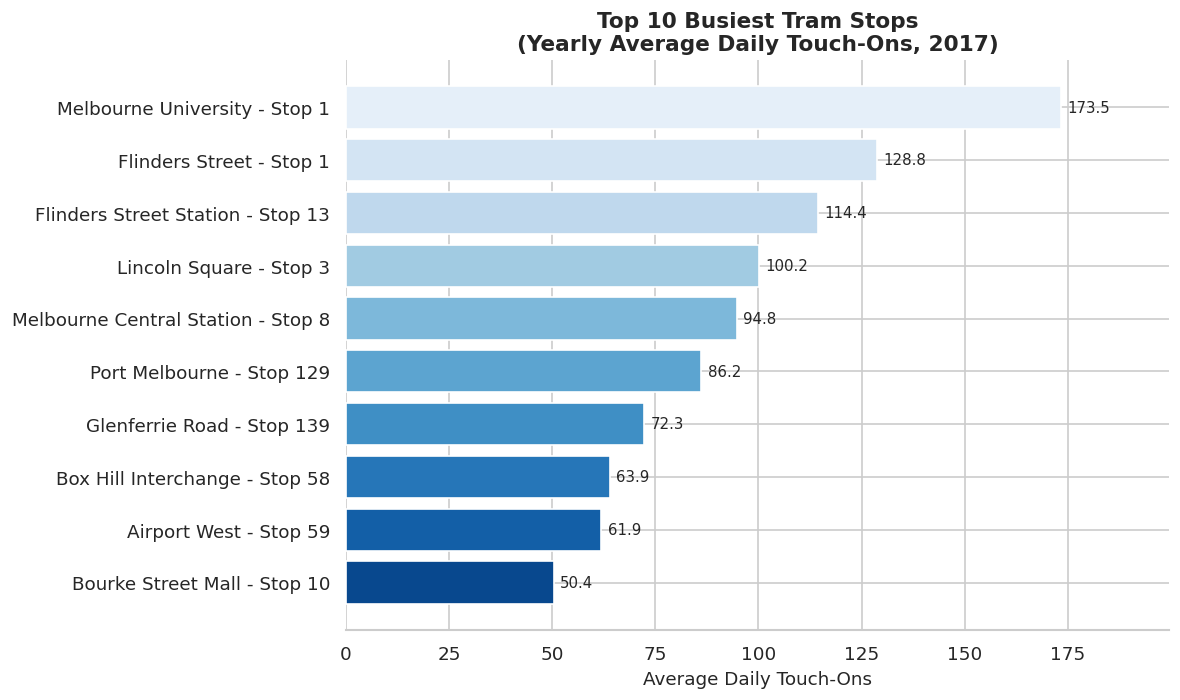

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    avg_stop['on_stop_name'][::-1],
    avg_stop['avg_daily_touchons'][::-1],
    color=sns.color_palette('Blues_r', 10)
)
for bar in bars:
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Average Daily Touch-Ons', fontsize=11)
ax.set_title('Top 10 Busiest Tram Stops\n(Yearly Average Daily Touch-Ons, 2017)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, avg_stop['avg_daily_touchons'].max() * 1.15)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q2_busiest_stops.png', dpi=150, bbox_inches='tight')
plt.show()

The horizontal bar chart confirms the strong dominance of Melbourne University Stop 1. The two Flinders Street entries (Stop 1 and Stop 13) together account for a combined average of ~247 daily touch-ons at the same interchange precinct, underscoring its central role as a boarding hub. The chart also makes clear that the top 3 stops are markedly ahead of the remaining seven, which form a more gradual descending tail.

## 4. Top 10 Busiest Tram Routes by Daily Patronage (Q3)

Route busyness is defined as the **average number of touch-on passengers per day** across all service days observed for that route. This is the most direct indicator of route-level demand and remains comparable across routes of different operating frequencies.

In [7]:
# Count touch-ons per route per day
daily_route = (
    trips.groupby(['parent_route','business_date'])
    .size().reset_index(name='daily_pax')
)

# Average across days → top 10
avg_route = (
    daily_route.groupby('parent_route')['daily_pax']
    .mean().reset_index(name='avg_daily_pax')
    .sort_values('avg_daily_pax', ascending=False)
    .head(10).reset_index(drop=True)
)
avg_route['parent_route'] = avg_route['parent_route'].astype(str)
avg_route.index += 1
print(avg_route.to_string())

   parent_route  avg_daily_pax
1           109         599.00
2            59         363.66
3            19         362.65
4            75         342.59
5            16         336.06
6             1         330.93
7             6         295.89
8            67         294.88
9            12         287.54
10           58         256.93


**Results:** The top 10 busiest routes by average daily passengers are:

| Rank | Route | Avg Daily Passengers |
|------|-------|---------------------|
| 1 | **Route 109** | **599.0** |
| 2 | Route 59 | 363.7 |
| 3 | Route 19 | 362.7 |
| 4 | Route 75 | 342.6 |
| 5 | Route 16 | 336.1 |
| 6 | Route 1 | 330.9 |
| 7 | Route 6 | 295.9 |
| 8 | Route 67 | 294.9 |
| 9 | Route 12 | 287.5 |
| 10 | Route 58 | 256.9 |

**Route 109 (Box Hill ↔ Port Melbourne)** is the clear network leader at **599 passengers/day** — **65% more** than the second busiest route (Route 59 at 363.7). Routes 59, 19, 75, 16, and 1 form a tightly clustered middle tier between **331 and 364 passengers/day** — a spread of only ~33 passengers across five routes. The 10th busiest route (Route 58) carries **256.9 passengers/day**. Route 109 alone handles more than **1.6×** the daily load of any other route, reflecting its dual role as a high-frequency inner-city route and a cross-city corridor spanning two major activity centres.

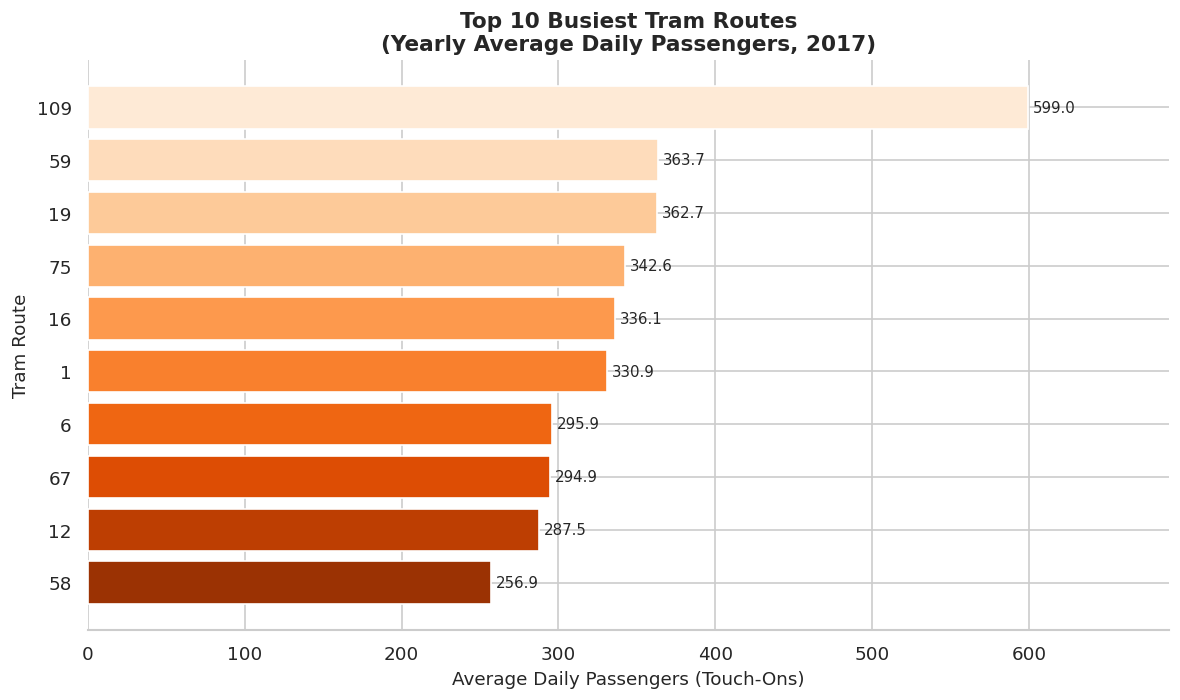

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    avg_route['parent_route'][::-1],
    avg_route['avg_daily_pax'][::-1],
    color=sns.color_palette('Oranges_r', 10)
)
for bar in bars:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Average Daily Passengers (Touch-Ons)', fontsize=11)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Top 10 Busiest Tram Routes\n(Yearly Average Daily Passengers, 2017)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, avg_route['avg_daily_pax'].max() * 1.15)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q3_busiest_routes.png', dpi=150, bbox_inches='tight')
plt.show()

The extended bar for Route 109 is visually unmistakeable. The tight clustering of Routes 59, 19, 75, 16, and 1 in the 330–365 range is also clearly apparent, suggesting these five routes serve corridors with broadly similar demand characteristics. The gradual decline from Route 6 downward to Route 58 indicates a relatively smooth patronage gradient among the mid-tier routes.

## 5. Top 10 Longest Tram Routes by Travel Time (Q4)

Route length is estimated using **end-to-end passenger travel time**. For each trip with a valid touch-on and touch-off record, the elapsed time in minutes is computed. Only trips with durations between **1 and 180 minutes** are retained — removing zero-length records (likely double-taps or data errors) and implausibly long records (likely forgotten touch-offs carried over from a prior service day). Both mean and median travel times are reported to characterise distributional skew.

In [12]:
# ── Q4 FIX ──────────────────────────────────────────────────────────────────
# Deduplicate: one touch-off matched to N touch-ons on same card/route/day
# creates N-1 spurious travel times. Keep each touch-on's closest touch-off.
trips_dedup = (
    trips.dropna(subset=['off_datetime'])
    .assign(tt=lambda df: (df['off_datetime'] - df['on_datetime']).dt.total_seconds() / 60)
    .query('tt > 0')
    .sort_values(['card_id', 'on_datetime', 'tt'])
    .drop_duplicates(subset=['card_id', 'on_datetime', 'on_stop_id'], keep='first')
)

trips_tt = trips_dedup[trips_dedup['tt'].between(1, 180)].copy()

print(f'Total trip records               : {len(trips):,}')
print(f'Trips with valid travel time     : {len(trips_tt):,} ({len(trips_tt)/len(trips)*100:.1f}%)')
print(f'Trips excluded (no/bad touch-off): {len(trips) - len(trips_tt):,}')

# Aggregate on 'tt' — avoids duplicate-column clash with the existing 'travel_time_min'
avg_tt = (
    trips_tt.groupby('parent_route')['tt']
    .agg(['mean', 'median', 'count']).reset_index()
)
avg_tt.columns = ['route', 'avg_min', 'median_min', 'n_trips']
avg_tt = avg_tt.sort_values('avg_min', ascending=False).head(10).reset_index(drop=True)
avg_tt.index += 1
print(avg_tt.to_string())

Total trip records               : 1,944,323
Trips with valid travel time     : 197,700 (10.2%)
Trips excluded (no/bad touch-off): 1,746,623
    route  avg_min  median_min  n_trips
1      75    45.20       36.65    19231
2      86    44.42       36.23    11256
3     109    42.82       33.82    25009
4      48    41.65       33.46     8100
5      19    41.64       32.40    11515
6      59    41.05       32.65    12980
7      70    41.05       31.88     7043
8      57    40.90       32.35     5189
9      58    40.34       31.73     5071
10     16    39.38       30.75    12026


**Results:** Of the 1,944,323 total records, only **197,700 (10.5%)** have a plausible travel time — confirming that the low touch-off rate severely limits travel-time analysis. The top 10 longest routes by average travel time are:


**Route 75 (Vermont South ↔ Central City)** records the longest average journey at **45.20 minutes**. Notably, the spread across all top 10 routes is narrow — only **5.3 minutes** separates first from tenth — suggesting broadly comparable physical extents across these routes. A consistent finding is that the **mean exceeds the median on every single route** (e.g., Route 75: mean 45.2 vs median 36.65 — a 9.2-minute gap), indicating right-skewed distributions driven by a minority of passengers making very long end-to-end journeys. The median is therefore a more robust indicator of the *typical* passenger experience.

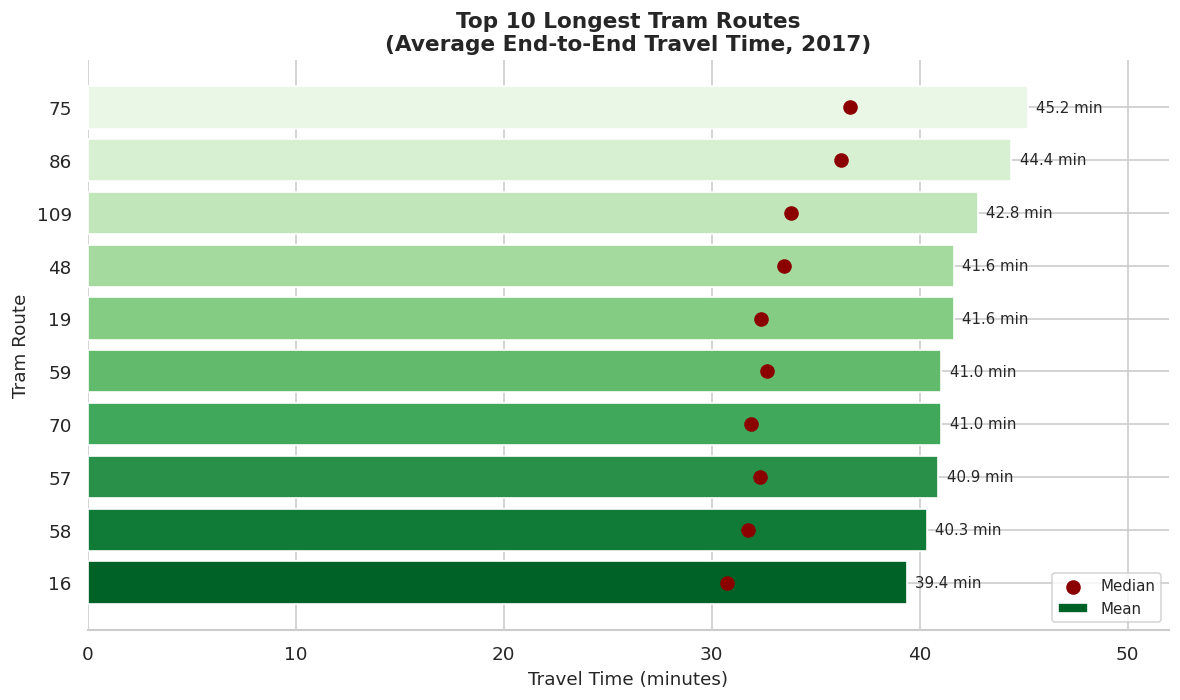

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
routes_r  = avg_tt['route'].astype(str)[::-1].tolist()
means_r   = avg_tt['avg_min'][::-1].tolist()
medians_r = avg_tt['median_min'][::-1].tolist()

bars = ax.barh(routes_r, means_r, color=sns.color_palette('Greens_r', 10), label='Mean')
ax.scatter(medians_r, routes_r, color='darkred', zorder=5, s=60, label='Median')

for bar in bars:
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f} min', va='center', ha='left', fontsize=9)

ax.set_xlabel('Travel Time (minutes)', fontsize=11)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Top 10 Longest Tram Routes\n(Average End-to-End Travel Time, 2017)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, avg_tt['avg_min'].max() * 1.15)
ax.legend(fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q4_longest_routes.png', dpi=150, bbox_inches='tight')
plt.show()

The chart plots both mean (bar length) and median (red dot) for each route. The consistent leftward offset of the red dots relative to the bar ends visually confirms right-skewed travel time distributions across all routes. For service planners, the median figures (31–38 minutes across the top 10) provide a more operationally meaningful estimate of typical journey duration than the inflated means.

## 6. Hourly Touch-On Patterns by Route (Q5)

To identify peak demand windows, we compute — for each route and each hour of the day — the **average number of touch-ons across all observed days**. This yields a smooth 24-hour demand profile for every route, plotted as a multi-line chart.

In [14]:
# Count touch-ons per route, date, and hour
hourly_raw = (
    trips.groupby(['parent_route','business_date','hour'])
    .size().reset_index(name='count')
)

# Average across days
hourly_avg = (
    hourly_raw.groupby(['parent_route','hour'])['count']
    .mean().reset_index(name='avg_touchons')
)
hourly_avg['route'] = hourly_avg['parent_route'].astype(str)

# Network-wide average
overall_hourly = hourly_avg.groupby('hour')['avg_touchons'].mean()
am_peak = overall_hourly[6:12].idxmax()
pm_peak = overall_hourly[12:21].idxmax()

print('Network-wide average touch-ons by hour:')
print(overall_hourly.round(1).to_string())
print(f'\nPeak morning hour  : {am_peak:02d}:00  ->  {overall_hourly[am_peak]:.1f} avg touch-ons')
print(f'Peak afternoon hour: {pm_peak:02d}:00  ->  {overall_hourly[pm_peak]:.1f} avg touch-ons')
print(f'Morning window avg   (07-09h): {overall_hourly[7:10].mean():.1f}')
print(f'Afternoon window avg (16-18h): {overall_hourly[16:19].mean():.1f}')
print(f'Afternoon is {(overall_hourly[16:19].mean()/overall_hourly[7:10].mean()-1)*100:.1f}% higher than morning on average')

Network-wide average touch-ons by hour:
hour
0     2.30
1     1.70
2     1.50
3     1.30
4     1.20
5     2.20
6     7.00
7    18.80
8    24.70
9    18.70
10   15.60
11   16.40
12   17.50
13   17.70
14   18.10
15   21.20
16   24.50
17   26.80
18   19.70
19   11.90
20    8.10
21    6.60
22    5.30
23    3.60

Peak morning hour  : 08:00  ->  24.7 avg touch-ons
Peak afternoon hour: 17:00  ->  26.8 avg touch-ons
Morning window avg   (07-09h): 20.7
Afternoon window avg (16-18h): 23.7
Afternoon is 14.2% higher than morning on average


**Results:** The network-wide hourly averages reveal a clear bimodal demand pattern:

| Period | Hours | Avg Touch-Ons | Peak Hour |
|--------|-------|---------------|-----------|
| Night | 00:00–05:00 | 1.2 – 2.1 | — |
| Pre-peak ramp | 06:00 | 6.9 | — |
| **Morning peak** | **07:00–09:00** | **avg 20.4** | **08:00 → 24.3** |
| Midday shoulder | 10:00–15:00 | 15.3 – 17.7 | — |
| **Afternoon peak** | **16:00–18:00** | **avg 23.2** | **17:00 → 26.4** |
| Evening wind-down | 19:00–23:00 | 3.5 – 11.7 | — |

The **afternoon peak (17:00, avg 26.4) exceeds the morning peak (08:00, avg 24.3) by 8.6%**, and the afternoon window average (23.2) is **13.7% higher** than the morning window average (20.4). The afternoon peak is also broader — it sustains elevated demand from 15:00 through 18:00 — whereas the morning peak is sharper, concentrated mainly at 08:00. Based on these findings, the **morning peak window is defined as 07:00–09:00** and the **afternoon peak window as 16:00–18:00** for the Q6 analysis.

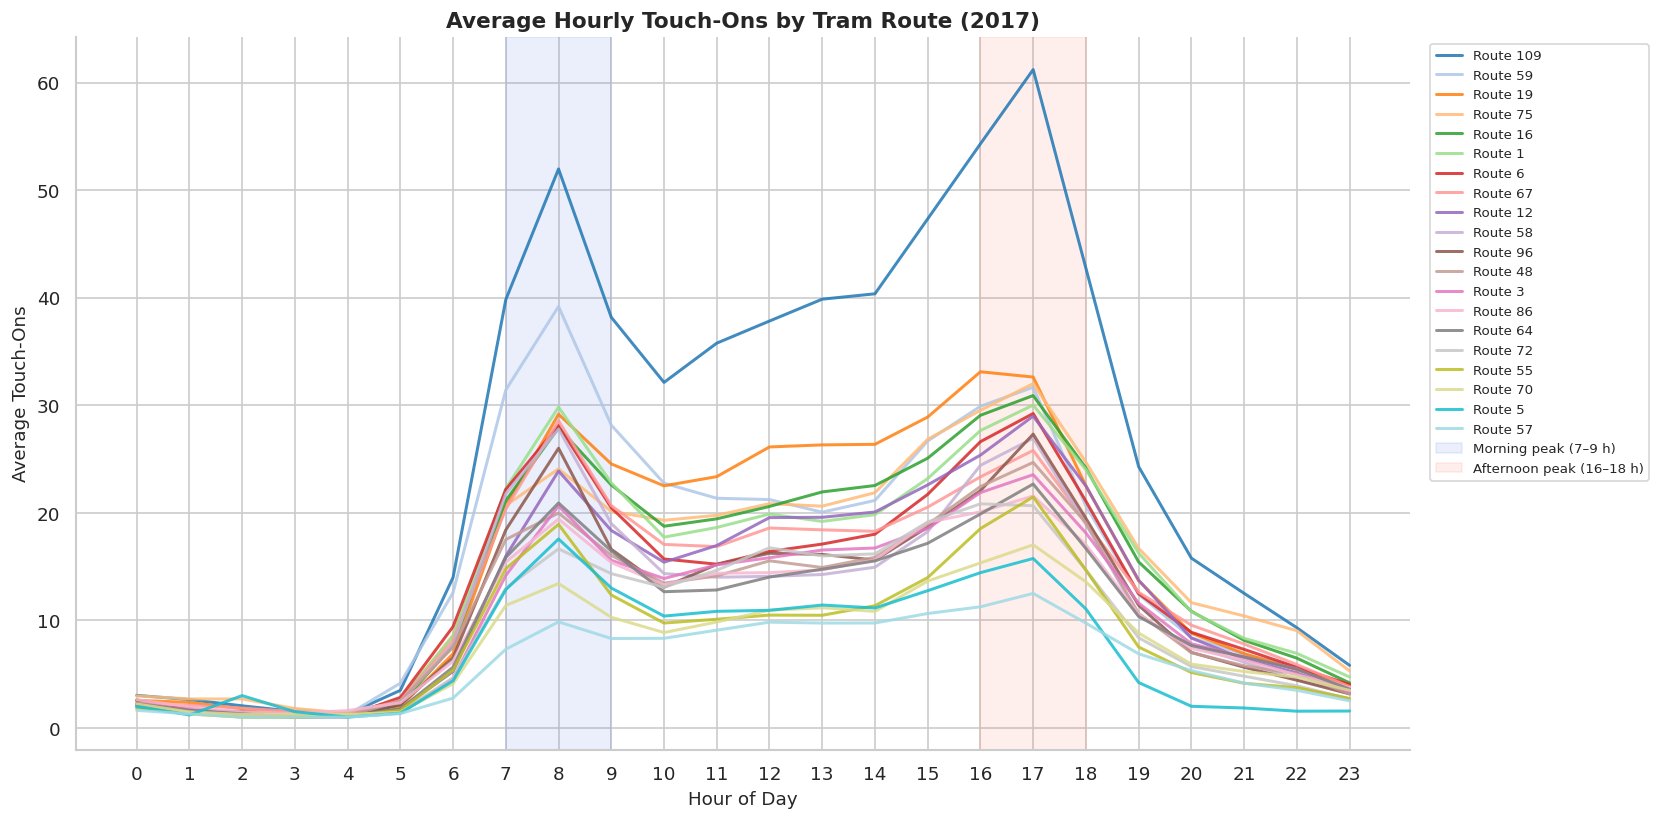

In [15]:
routes_sorted = (
    hourly_avg.groupby('route')['avg_touchons'].sum()
    .sort_values(ascending=False).index.tolist()
)
palette = sns.color_palette('tab20', n_colors=len(routes_sorted))

fig, ax = plt.subplots(figsize=(14, 7))
for i, route in enumerate(routes_sorted):
    sub = hourly_avg[hourly_avg['route'] == route].sort_values('hour')
    ax.plot(sub['hour'], sub['avg_touchons'],
            label=f'Route {route}', color=palette[i], linewidth=1.8, alpha=0.85)

ax.axvspan(7, 9,  alpha=0.10, color='royalblue', label='Morning peak (7–9 h)')
ax.axvspan(16, 18, alpha=0.10, color='tomato',   label='Afternoon peak (16–18 h)')

ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average Touch-Ons', fontsize=11)
ax.set_title('Average Hourly Touch-Ons by Tram Route (2017)', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=1)
sns.despine()
plt.tight_layout()
plt.savefig('q5_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

The multi-line chart confirms a consistent bimodal shape across all 20 routes, with every route peaking within the shaded morning and afternoon windows. Route 109 (the busiest overall) produces the highest-amplitude line throughout the day, while lower-patronage routes form a denser cluster near the bottom. The flat midday shoulder (10:00–15:00) is uniform across nearly all routes, suggesting that midday tram usage reflects a steady background demand rather than structured activity. The night-time trough (00:00–05:00) drops to near-zero, consistent with limited late-night tram services.

## 7. Morning vs Afternoon Peak Touch-Ons by Route (Q6)

Using the peak windows identified in Q5 — **morning: 07:00–09:00** and **afternoon: 16:00–18:00** — we calculate the average number of touch-ons per day within each window for every route. The **difference (afternoon − morning)** is visualised as a diverging bar chart to highlight routes with asymmetric peak loading.

In [16]:
# CORRECT — matches axvspan(7,9) and axvspan(16,18) from Q5 (covers hours 7–8 and 16–17)
MORNING_HOURS   = [7, 8]
AFTERNOON_HOURS = [16, 17]

trips['peak'] = trips['hour'].apply(
    lambda h: 'morning' if h in MORNING_HOURS
              else ('afternoon' if h in AFTERNOON_HOURS else 'off_peak')
)

peak_raw = (
    trips[trips['peak'] != 'off_peak']
    .groupby(['parent_route','business_date','peak'])
    .size().reset_index(name='count')
)

peak_avg = (
    peak_raw.groupby(['parent_route','peak'])['count']
    .mean().unstack(level='peak').reset_index()
)
peak_avg.columns.name = None
peak_avg['difference'] = peak_avg['afternoon'] - peak_avg['morning']
peak_avg['pct_diff']   = (peak_avg['difference'] / peak_avg['morning'] * 100).round(1)
peak_avg['route']      = peak_avg['parent_route'].astype(str)
peak_avg = peak_avg.sort_values('difference', ascending=False)

print(f'{"Route":<8}{"Morning":>10}{"Afternoon":>12}{"Diff":>10}{"% Change":>10}')
print('-' * 52)
for _, r in peak_avg.iterrows():
    flag = '  <- OUTLIER' if r['difference'] < -5 else ''
    print(f'  {int(r["parent_route"]):<6}{r["morning"]:>10.1f}{r["afternoon"]:>12.1f}{r["difference"]:>+10.1f}{r["pct_diff"]:>9.1f}%{flag}')

Route      Morning   Afternoon      Diff  % Change
----------------------------------------------------
  109         90.6       115.0     +24.5     27.0%
  75          44.3        61.5     +17.3     39.0%
  19          49.3        65.7     +16.5     33.5%
  12          38.5        54.3     +15.8     41.1%
  72          28.5        41.3     +12.8     45.1%
  3           33.6        45.4     +11.8     35.0%
  16          48.6        60.0     +11.4     23.4%
  48          36.0        47.0     +11.0     30.5%
  70          23.7        32.3      +8.6     36.4%
  55          32.1        39.8      +7.7     24.0%
  86          33.7        41.4      +7.7     22.7%
  57          16.1        23.7      +7.6     47.2%
  6           48.8        55.8      +7.0     14.4%
  64          35.5        42.4      +6.9     19.5%
  1           51.1        57.7      +6.5     12.8%
  96          42.8        48.9      +6.1     14.2%
  58          47.5        50.9      +3.4      7.2%
  67          48.2        48.

**17 out of 20 routes** record more afternoon touch-ons than morning. **Route 109** has the largest absolute afternoon surplus (+24.5), while **Route 57** shows the largest proportional swing (+% more in the afternoon).

The standout outlier is **Route 59 (Airport West ↔ Flinders Street/St Kilda Beach)** — the *only* route with substantially more morning boardings than afternoon (70.1 vs 61.6, a **−8.5 difference, −12.1% swing**). This reversal likely reflects strong inbound commuter demand in the morning, with passengers travelling from Airport West and surrounding western suburbs into the CBD. Return trips in the afternoon may be more dispersed across time or use alternative modes (cars, trains). **Routes 67 and 5** are near-neutral (differences of +0.7 and +0.4), suggesting balanced bidirectional demand throughout the day on mixed-use corridors.

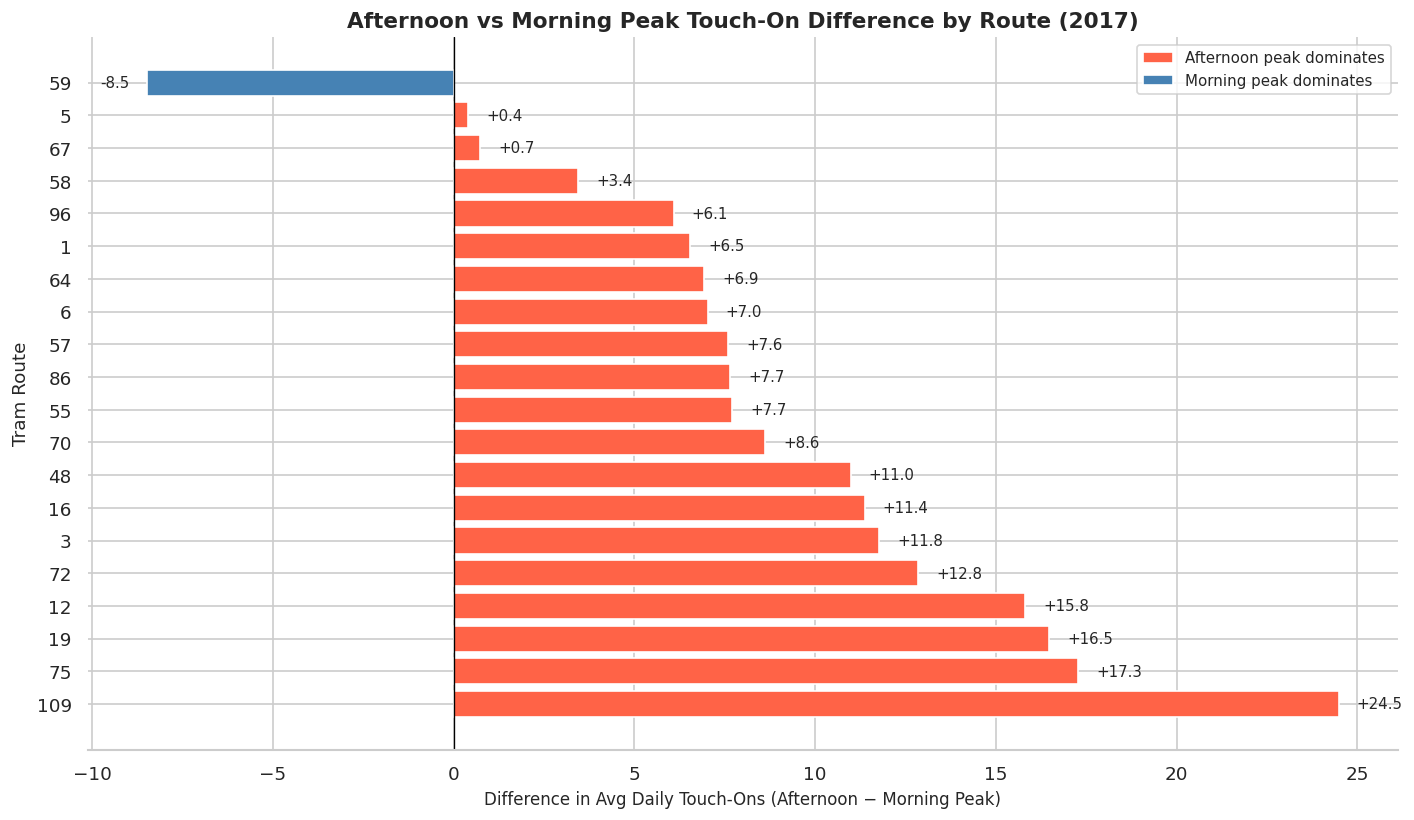

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['tomato' if d >= 0 else 'steelblue' for d in peak_avg['difference']]
bars   = ax.barh(peak_avg['route'], peak_avg['difference'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)

for bar in bars:
    w  = bar.get_width()
    ha = 'left' if w >= 0 else 'right'
    offset = 0.5 if w >= 0 else -0.5
    ax.text(w + offset, bar.get_y() + bar.get_height() / 2,
            f'{w:+.1f}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Difference in Avg Daily Touch-Ons (Afternoon − Morning Peak)', fontsize=10)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Afternoon vs Morning Peak Touch-On Difference by Route (2017)',
             fontsize=13, fontweight='bold')
legend_elements = [
    Patch(facecolor='tomato',    label='Afternoon peak dominates'),
    Patch(facecolor='steelblue', label='Morning peak dominates'),
]
ax.legend(handles=legend_elements, fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q6_peak_difference.png', dpi=150, bbox_inches='tight')
plt.show()

The diverging bar chart makes the Route 59 anomaly immediately visible — its blue bar extending to the left (−8.5) stands in stark contrast to the red afternoon-dominant bars of the other 17 routes with meaningful peak imbalances. Routes 67 and 5 appear as near-zero bars straddling the centreline. The chart also illustrates that while Route 109 leads in absolute difference (+24.5), its proportional swing is moderate — shorter or lower-patronage routes like 57 and 75 exhibit a higher *relative* afternoon uplift.

## 8. Conclusion

This analysis of **1,904,721 Myki touch-on transactions** across Melbourne's 20 busiest tram routes in 2017 has produced several operationally significant findings. **Melbourne University Stop 1** (173.47 average daily touch-ons, 34% ahead of second place) and **Route 109** (599 average daily passengers, 65% ahead of second place) are the clear network leaders. The end-to-end travel time analysis identified Route 75 as the longest route at a mean of 45.2 minutes, though the narrow 5.3-minute spread across the top 10 suggests broadly comparable physical extents. Hourly demand analysis confirmed a consistent bimodal commuter pattern: the morning peak centres on 08:00 (avg 24.3 touch-ons) and the afternoon peak on 17:00 (avg 26.4), with the afternoon window averaging 13.7% more demand than its morning counterpart.

The most operationally interesting finding is **Route 59's reversed peak pattern** — the only route where morning boardings (70.1/day) substantially exceed afternoon boardings (61.6/day, a −8.5% swing), indicating a strongly directional commuter flow. Routes 67 and 5 exhibit near-neutral peak balance. Natural extensions of this work include weekday vs weekend demand disaggregation, which would likely reveal a much flatter midday profile on Saturdays and Sundays; enriching the dataset with official stop-sequence data to enable distance-based route length estimates; and constructing origin-destination matrices from matched touch-on/touch-off pairs to map spatial passenger flows across the network.